In [1]:
import torch
import matplotlib.pyplot as plt
import os
import time
import numpy as np
import random
from matplotlib.patches import Rectangle
import tifffile
import h5py
from torch.utils.data import DataLoader
import imageio.v2 as imageio
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Patch

import importlib as imp
import sys
sys.path.append(os.path.join(os.path.split(os.getcwd())[0], 'scripts'))

import yolo_tiles
imp.reload(yolo_tiles)
from yolo_tiles import img_to_tiles, apply_model_to_tiles, load_test_image, preprocess, tileDataset, remove_bbox_in_overlap

import yolo_help
imp.reload(yolo_help)
from yolo_help import bbox_to_rectangles, imshow, convert_data, Net, get_best_bounding_box_per_cell

import yolo_post_help
imp.reload(yolo_post_help)
from yolo_post_help import remove_low_conf_bboxes, postprocess, bb_to_rec, NMS

import yolo_help_3D
imp.reload(yolo_help_3D)
from yolo_help_3D import apply_model_to_orthogonal_slices, gen_3D_GT, recon_down, vol_to_mip_rgb, orthogonal_to_3D, vol_to_mip

import yolo_avg_prec
imp.reload(yolo_avg_prec)
from yolo_avg_prec import get_AP, gt_bbox_to_pred_bbox_format, IOU_3D, yolo_output_to_list

import yolo_3D_pipeline_help
imp.reload(yolo_3D_pipeline_help)
from yolo_3D_pipeline_help import apply_2D_yolo_to_slices, stitch_slices_into_cube

#sys.path.append('/home/dtward/Documents/UCLA/stardist')
#from stardist.models import StarDist3D
import nibabel as nib

from csbdeep.utils import normalize

#sys.path.append('/ifshome/abenneck/docs_public/libraries/cellpose')
#from cellpose import models

2026-09-09 10:49:12.498911: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def bb_slice_filter(all_bb, ax_idx, slice_val):
    """
    NOTE: Each elem of all_bb should have at minimum these first 6 values [ax0_min, ax0_max, ax1_min, ax1_max, ax2_min, ax2_max, ...]
    """
    bb_out = []
    for bb in all_bb:
        if ax_idx == 0 and bb[0] <= slice_val and bb[1] >= slice_val:
            bb_out.append(bb)
        elif ax_idx == 1 and bb[2] <= slice_val and bb[3] >= slice_val:
            bb_out.append(bb)
        elif ax_idx == 2 and bb[4] <= slice_val and bb[5] >= slice_val:
            bb_out.append(bb)
        else:
            continue

    if bb_out == []:
        return np.array([])
    return np.stack(bb_out, axis=0)

def gt_mask_to_bb_list(mask_path, verbose=False):
    """
    Converts an integer-valued array into a set of bounding boxes around each unique instance.
    """
    # Load the GT annotation
    mask = nib.load(mask_path)
    
    # 0: Bg, 1: Annotated bg, 2+: Cell ID
    gt_bb = []
    vals_to_skip = [0, 1]
    n_cells = len(np.unique(mask.get_fdata())) - 2 # 0 is bg and 1 is annotated bg
    for val in np.unique(mask.get_fdata()):
        if val in vals_to_skip:
            continue
        mask_cell = np.copy(mask.get_fdata())
        mask_cell[mask_cell != val] = 0.0
        mask_cell[mask_cell == val] = 1.0
        if verbose:
            print(f'Cell {(val-1).astype(int)} / {n_cells} volume of {np.sum(mask_cell).astype(int)} voxels')
        all_x, all_y, all_z = np.where(mask_cell == 1.0)
        gt_bb.append([min(all_x).item(), max(all_x).item(), min(all_y).item(), max(all_y).item(), min(all_z).item(), max(all_z).item(), int(val)])

    return gt_bb

def yolo_output_to_bb_list(out):
    return out.reshape(out.shape[0]*out.shape[1]*out.shape[2],out.shape[3])

def stardist_to_bb_list(raw_output, mode='2D'):
    """
    Converts a standard output from the 2D or 3D StarDist models to a set of bounding boxes
    """

    bb_out = []
    if mode == '2D':
        for i in range(len(raw_output['coord'])):
            coords = raw_output['coord'][i]
            center = raw_output['points'][i]
            prob = float(raw_output['prob'][i])
    
            xmin = float(min(coords[1]))
            xmax = float(max(coords[1]))
            ymin = float(min(coords[0]))
            ymax = float(max(coords[0]))
    
            bb_out.append([xmin, xmax, ymin, ymax, prob])
    elif mode == '3D':
        n_ray = raw_output['dist'].shape[1]
        n_cells = raw_output['dist'].shape[0]
        n_dim = raw_output['points'].shape[1]
        for i in range(n_cells):
            prob = raw_output['prob'][i]
            center = raw_output['points'][i]
            n_vectors = [raw_output['rays_vertices'][j]*raw_output['dist'][i][j] for j in range(n_ray)]
            n_vectors = np.asarray(n_vectors) + center
        
            xmin, ymin, zmin = np.min(n_vectors, axis=0)
            xmax, ymax, zmax = np.max(n_vectors, axis=0)
        
            bb_out.append([xmin, xmax, ymin, ymax, zmin, zmax, prob])
    else:
        print(f'Invalid mode - {mode}; Expected 2D or 3D')
        
    return np.asarray(bb_out)

def cellpose_to_bb_list(mask, verbose=False):
    """
    Converts an integer-valued array into a set of bounding boxes around each unique instance.

    Output bbox format: [xmin xmax ymin ymax zmin zmax cell# conf]
    """
    # 0: Bg, 1+: Cell ID
    bb_out = []
    vals_to_skip = [0]
    n_cells = len(np.unique(mask)) - 1 # 0 is bg
    for val in np.unique(mask):
        if val in vals_to_skip:
            continue
        mask_cell = np.copy(mask)
        mask_cell[mask_cell != val] = 0.0
        mask_cell[mask_cell == val] = 1.0
        if verbose:
            print(f'Cell {(val-1).astype(int)} / {n_cells} volume of {np.sum(mask_cell).astype(int)} voxels')
        all_x, all_y, all_z = np.where(mask_cell == 1.0)
        bb_out.append([min(all_x).item(), max(all_x).item(), min(all_y).item(), max(all_y).item(), min(all_z).item(), max(all_z).item(), int(val), 1.0])
    return np.array(bb_out)

def preprocess_3D(img, upsample = True, gamma = True, norm = True):

    img_out = np.copy(img)
    
    # Apply a gamma correction (gamma = 1/2)
    if gamma:
        img_out = img_out**(1/2)

    # Normalize the image to [0,1]
    if normalize:
        # img_min = np.min(img,axis=(-1,-2,-3),keepdims=True)
        # img_max = np.max(img,axis=(-1,-2,-3),keepdims=True)
        # img_out = (img_out - img_min) / (img_max - img_min)
        img_out = normalize(img_out)
        
    # Upsample the image by a factor of 2 (Inc the size of each voxel from 1 to 2x2x2)
    if upsample:
        out_shape = [i*2 for i in img.shape]
        img_up = np.zeros(out_shape)
    
        img_up[::2,::2,::2]   = img_out
        img_up[::2,1::2,::2]  = img_out
        img_up[1::2,::2,::2]  = img_out
        img_up[1::2,1::2,::2] = img_out
        
        img_up[::2,::2,1::2]   = img_out
        img_up[::2,1::2,1::2]  = img_out
        img_up[1::2,::2,1::2]  = img_out
        img_up[1::2,1::2,1::2] = img_out

        img_out = img_up

    return img_out

# Convert all bb coords in 'bb_list' to the appropriate coordinate space (relative to the annotated region, with origin in the upper left corner)
def convert_bb_units(bb_list):
    bb_out = []
    for bb in bb_list:
        new_bb = [2*(val-96) for val in bb[:6]]
        new_bb.extend(bb[6:])
        bb_out.append(new_bb)
    return np.array(bb_out)

def remove_low_conf_bb(data, conf_idx = -4):
    """
    Remove all bboxes with a conf of 0, so that they won't be considered when computing AP
    """
    data_out = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            for k in range(data.shape[2]):
                if data[i,j,k,conf_idx] > 0:
                    data_out.append(data[i,j,k])
    return np.array(data_out)

# (0) Load all the models, the target volume, and the associated annotation

In [4]:
# Load the YOLO model
model_path = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo_saved_weights/modelsave_bright_on_dark.pt'
net = Net()
net.load_state_dict(torch.load(model_path))
B = net.B
stride = net.stride
print('Successfully loaded YOLO model . . .')

## Load the Stardist model
#star_model = StarDist3D.from_pretrained('3D_demo')
#print('Successfully loaded StarDist model . . .')

## Load the Cellpose model (ALL pretrained model weights: ["cpsam_v2" (DEFAULT), "cpdino", "cpdino-vitb", "cpsam"])
#cell_model = models.CellposeModel(gpu=False, pretrained_model="cpsam_v2")
#print('Successfully loaded CellPose model . . .')

# Load the target volume
indir = os.path.join(os.path.split(os.getcwd())[0], 'inputs')
img_path = os.path.join(indir, 'cube_i0002_j0005_k0003.nii.gz')
img = nib.load(img_path)
img = img.get_fdata()
print('Successfully loaded target volume . . .')

# Load the GT annotation + convert to list(bbox)
mask_path = os.path.join(indir, 'mask64_i0002_j0005_k0003_annotated.nii.gz')
mask = nib.load(mask_path)
mask = mask.get_fdata()
gt_bb = gt_mask_to_bb_list(mask_path) # Convert integer-valued img into a list of bboxes
print(f'Successfully loaded GT annotations ({len(gt_bb)} total cells) . . .')

Successfully loaded YOLO model . . .
Successfully loaded target volume . . .
Successfully loaded GT annotations (276 total cells) . . .


### Visualize img + GT annotations

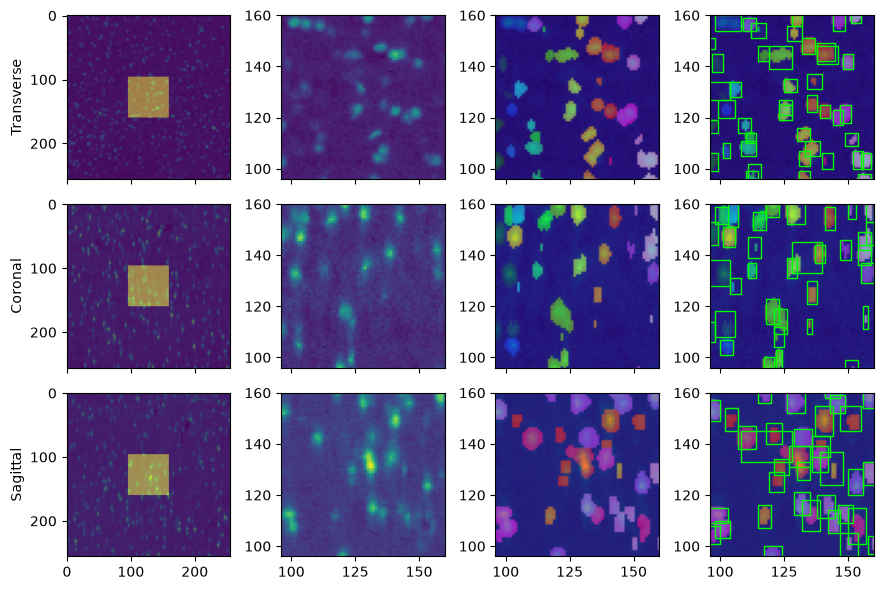

In [4]:
img0 = img[img.shape[0]//2,:,:]
img1 = img[:,img.shape[1]//2,:]
img2 = img[:,:,img.shape[2]//2]

mask0 = mask[mask.shape[0]//2,:,:]
mask1 = mask[:,mask.shape[1]//2,:]
mask2 = mask[:,:,mask.shape[2]//2]

#boundary_mask_path = '/ifshome/abenneck/docs_public/misc_outputs/gt_data/mask64_i0002_j0005_k0003.nii.gz'
boundary_mask_path = '~/mounts/bmaproot/ifshome/abenneck/docs_public/misc_outputs/gt_data/mask64_i0002_j0005_k0003.nii.gz'
boundary_mask = nib.load(boundary_mask_path)
boundary_mask = boundary_mask.get_fdata()

boundary_mask0 = boundary_mask[boundary_mask.shape[0]//2,:,:]
boundary_mask1 = boundary_mask[:,boundary_mask.shape[1]//2,:]
boundary_mask2 = boundary_mask[:,:,boundary_mask.shape[2]//2]

lim = [96,160]

fig, axs = plt.subplots(3, 4, layout='tight', sharex='col')
axs[0,0].imshow(img0)
axs[0,0].imshow(boundary_mask0, alpha = 0.5)
axs[0,1].imshow(img0)
axs[0,2].imshow(img0)
axs[0,2].imshow(mask0, cmap = 'gist_ncar', alpha = 0.5)
axs[0,3].imshow(img0)
axs[0,3].imshow(mask0, cmap = 'gist_ncar', alpha = 0.5)
bb_plot = bb_to_rec(bb_slice_filter(gt_bb, 0, img.shape[0]//2), pos = [4, 2, 5, 3], fc='none', ec='lime')
axs[0,3].add_collection(bb_plot)
axs[0,0].set_ylabel('Transverse')

axs[1,0].imshow(img1)
axs[1,0].imshow(boundary_mask1, alpha = 0.5)
axs[1,1].imshow(img1)
axs[1,2].imshow(img1)
axs[1,2].imshow(mask1, cmap = 'gist_ncar', alpha = 0.5)
axs[1,3].imshow(img1)
axs[1,3].imshow(mask1, cmap = 'gist_ncar', alpha = 0.5)
bb_plot = bb_to_rec(bb_slice_filter(gt_bb, 1, img.shape[1]//2), pos = [4, 0, 5, 1], fc='none', ec='lime')
axs[1,3].add_collection(bb_plot)
axs[1,0].set_ylabel('Coronal')

axs[2,0].imshow(img2)
axs[2,0].imshow(boundary_mask2, alpha = 0.5)
axs[2,1].imshow(img2)
axs[2,2].imshow(img2)
axs[2,2].imshow(mask2, cmap = 'gist_ncar', alpha = 0.5)
axs[2,3].imshow(img2)
axs[2,3].imshow(mask2, cmap = 'gist_ncar', alpha = 0.5)
bb_plot = bb_to_rec(bb_slice_filter(gt_bb, 2, img.shape[2]//2), pos = [2, 0, 3, 1], fc='none', ec='lime')
axs[2,3].add_collection(bb_plot)
axs[2,0].set_ylabel('Sagittal')

for ax in axs:
    for ax_i in ax[1:]:
        ax_i.set_xlim(lim)
        ax_i.set_ylim(lim)

fig.set_size_inches(9,6)

### Compare original input img to preprocessed input img

In [5]:
'''
fig, axs = plt.subplots(1,2)

axs[0].imshow(img[0])
axs[0].set_title('Original')

axs[1].imshow(img_up[0])
axs[1].set_title('Preprocessing')
'''

"\nfig, axs = plt.subplots(1,2)\n\naxs[0].imshow(img[0])\naxs[0].set_title('Original')\n\naxs[1].imshow(img_up[0])\naxs[1].set_title('Preprocessing')\n"

# (1) Apply each model to the target volume

In [5]:
# Segment annotated region from original img, to dec memory cost
img_ann = img[96:160, 96:160, 96:160]
print(f'Annotated area size: {img_ann.shape}')

# In original dataset, avg cell diameter is 5-8 voxels, so upsamping inc this to 10-16 voxels
img_up = preprocess_3D(img_ann)
print(f'(Upsampled) Annotated area size: {img_up.shape}')

Annotated area size: (64, 64, 64)
(Upsampled) Annotated area size: (128, 128, 128)


In [7]:
# Apply YOLO (img is upsampled and gamma corrected)
start = time.time()
outdir_slices = '/home/dtward/mounts/bmaproot/ifshome/abenneck/docs_public/misc_outputs/gt_data/slices'
outdir_cube = '/home/dtward/mounts/bmaproot/ifshome/abenneck/docs_public/misc_outputs/gt_data/cube'
#apply_2D_yolo_to_slices(img_path, model_path, outdir_slices, verbose = False)
#yolo_out = stitch_slices_into_cube(os.path.join(outdir_slices,'ax0'), os.path.join(outdir_slices,'ax1'), os.path.join(outdir_slices,'ax2'), outdir_cube)
yolo_out = np.load('/ifshome/abenneck/docs_public/misc_outputs/gt_data/cube/i0000_j0000_k0000_d256_Ex_488_Em_525.npy')
conf_thresh=1e-3
nms_thresh=0.3
yolo_nms = NMS(yolo_out,conf_thresh=conf_thresh, nms_thresh=nms_thresh)
print(f'Finished applying YOLO model in {time.time() - start:.2f}s')

## Apply Stardist
#start = time.time()
#stardist_labels, stardist_raw_outputs = star_model.predict_instances(img_up)
#print(f'Finished applying StarDist model in {time.time() - start:.2f}s')

## Apply Cellpose
#img_3ch = img_up[None] # Add a channel dimension since, CellPose requires the input image to have "at least 3 channels"
#start = time.time()
#masks_stitched, flows_stitched, _ = cell_model.eval(img_3ch, z_axis=1, channel_axis=0,
#                                                  batch_size=32,
#                                                  do_3D=False, stitch_threshold=0.5)
#print(f'Finished applying CellPose model in {time.time() - start:.2f}s')

................................................................97.85% of bboxes removed
Finished applying YOLO model in 1.45s


### Visualize Data (Only the annotated area of s=64)

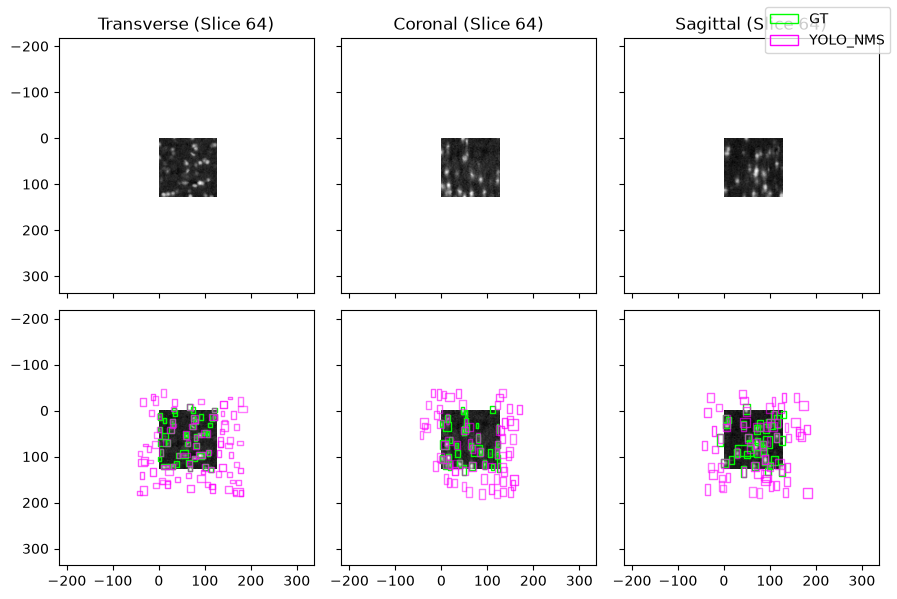

In [9]:
img_m0_idx = img_up.shape[0]//2
img_m1_idx = img_up.shape[1]//2
img_m2_idx = img_up.shape[2]//2

img0 = img_up[img_m0_idx,:,:]
img1 = img_up[:,img_m1_idx,:]
img2 = img_up[:,:,img_m2_idx]

lim = [96,160]

yolo_conf_thresh = 0.5
# yolo_bb = yolo_output_to_bb_list(yolo_out)
yolo_bb = yolo_output_to_bb_list(yolo_nms)
#star_bb = stardist_to_bb_list(stardist_raw_outputs, mode='3D')
#cell_bb = cellpose_to_bb_list(masks_stitched)

# Convert to relative units (YOLO and GT are in units of the original img, but Star and Cell are in units of the segmented, upsampled annotated region
gt_bb_adjusted = convert_bb_units(gt_bb)
yolo_bb_adjusted = convert_bb_units(yolo_bb)

# Each row will be a different angle, and each col will be (img, img+outputs)
fig, axs = plt.subplots(2,3,layout='tight', sharex=True, sharey=True)

# ==============================
# ===== Col 0 (Transverse) =====
# ==============================
# Original image
axs[0,0].imshow(img0, cmap='gray')
axs[0,0].set_title(f'Transverse (Slice {img_m0_idx})')

# Original image
axs[1,0].imshow(img0, cmap='gray')

# GT bboxes
bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb_adjusted, 0, img_m0_idx), pos = [4, 2, 5, 3], fc='none', ec='lime')
axs[1,0].add_collection(bb_plot_gt)

# YOLO bboxes
bb_yolo = bb_slice_filter(yolo_bb_adjusted, 0, img_m0_idx)
scores = bb_yolo[:,-4]
scores[scores < yolo_conf_thresh] = 0.0
bb_plot_yolo = bb_to_rec(bb_yolo, pos = [4, 2, 5, 3], fc='none', ec='magenta', alpha=scores)
axs[1,0].add_collection(bb_plot_yolo)


## Stardist bboxes
#bb_star = bb_slice_filter(star_bb, 0, img_m0_idx)
#if len(bb_star) > 0:
#    scores = bb_star[:,-1]
#    bb_plot_star = bb_to_rec(bb_star, pos = [4, 2, 5, 3], fc='none', ec='red', alpha=scores)
#    axs[1,0].add_collection(bb_plot_star)

## CellPose bboxes
#bb_cell = bb_slice_filter(cell_bb, 0, img_m0_idx)
#if len(bb_cell) > 0:
#    bb_plot_cell = bb_to_rec(bb_cell, pos = [4, 2, 5, 3], fc='none', ec='c')
#    axs[1,0].add_collection(bb_plot_cell)

# ===========================
# ===== Col 1 (Coronal) =====
# ===========================
# Original image
axs[0,1].imshow(img1, cmap='gray')
axs[0,1].set_title(f'Coronal (Slice {img_m1_idx})')

# Original image
axs[1,1].imshow(img1, cmap='gray')

# GT bboxes
bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb_adjusted, 1, img_m1_idx), pos = [4, 0, 5, 1], fc='none', ec='lime')
axs[1,1].add_collection(bb_plot_gt)

# YOLO bboxes
bb_yolo = bb_slice_filter(yolo_bb_adjusted, 1, img_m1_idx)
scores = bb_yolo[:,-4]
scores[scores < yolo_conf_thresh] = 0.0
bb_plot_yolo = bb_to_rec(bb_yolo, pos = [4, 0, 5, 1], fc='none', ec='magenta', alpha=scores)
axs[1,1].add_collection(bb_plot_yolo)

# Stardist bboxes
#bb_star = bb_slice_filter(star_bb, 1, img_m1_idx)
#if len(bb_star) > 0:
#    scores = bb_star[:,-1]
#    bb_plot_star = bb_to_rec(bb_star, pos = [4, 0, 5, 1], fc='none', ec='red', alpha=scores)
#    axs[1,1].add_collection(bb_plot_star)

## CellPose bboxes
#bb_cell = bb_slice_filter(cell_bb, 1, img_m1_idx)
#if len(bb_cell) > 0:
#    bb_plot_cell = bb_to_rec(bb_cell, pos = [4, 0, 5, 1], fc='none', ec='c')
#    axs[1,1].add_collection(bb_plot_cell)


# ============================
# ===== Col 2 (Sagittal) =====
# ============================
# Original image
axs[0,2].imshow(img2, cmap='gray')
axs[0,2].set_title(f'Sagittal (Slice {img_m2_idx})')

# Original image
axs[1,2].imshow(img2, cmap='gray')

# GT bboxes
bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb_adjusted, 2, img_m2_idx), pos = [2, 0, 3, 1], fc='none', ec='lime')
axs[1,2].add_collection(bb_plot_gt)

# YOLO bboxes
bb_yolo = bb_slice_filter(yolo_bb_adjusted, 2, img_m2_idx)
scores = bb_yolo[:,-4]
scores[scores < yolo_conf_thresh] = 0.0
bb_plot_yolo = bb_to_rec(bb_yolo, pos = [2, 0, 3, 1], fc='none', ec='magenta', alpha=scores)
axs[1,2].add_collection(bb_plot_yolo)

## Stardist bboxes
#bb_star = bb_slice_filter(star_bb, 2, img_m2_idx)
#if len(bb_star) > 0:
#    scores = bb_star[:,-1]
#    bb_plot_star = bb_to_rec(bb_star, pos = [2, 0, 3, 1], fc='none', ec='red', alpha=scores)
#    axs[1,2].add_collection(bb_plot_star)

## CellPose bboxes
#bb_cell = bb_slice_filter(cell_bb, 2, img_m2_idx)
#if len(bb_cell) > 0:
#    bb_plot_cell = bb_to_rec(bb_cell, pos = [2, 0, 3, 1], fc='none', ec='c')
#    axs[1,2].add_collection(bb_plot_cell)

# ========================
# ===== Whole Figure =====
# ========================

# Set same limits for every view
# for ax in axs:
#     for ax_i in ax:
#         ax_i.set_xlim(lim)
#         ax_i.set_ylim(lim)

# Generate a legend for the figure
legend_handles = [
    Patch(facecolor='none', edgecolor="lime", label="GT"),
    Patch(facecolor='none', edgecolor="magenta", label="YOLO_NMS"),
    #Patch(facecolor='none', edgecolor="red", label="Stardist"),
    #Patch(facecolor='none', edgecolor="c", label="CellPose"),
]
fig.legend(handles=legend_handles)

fig.set_size_inches(9,6)

### Plot all bb pruned during NMS

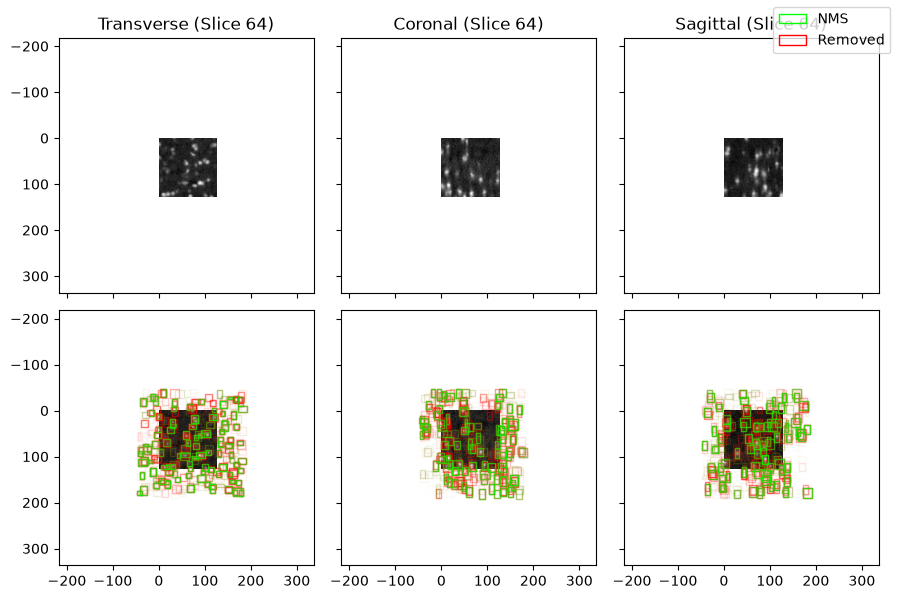

In [10]:
img_m0_idx = img_up.shape[0]//2
img_m1_idx = img_up.shape[1]//2
img_m2_idx = img_up.shape[2]//2

img0 = img_up[img_m0_idx,:,:]
img1 = img_up[:,img_m1_idx,:]
img2 = img_up[:,:,img_m2_idx]

lim = [96,160]

# Convert YOLO outputs into lists of bboxes
yolo_bb = yolo_output_to_bb_list(yolo_out)
yolo_bb_nms = yolo_output_to_bb_list(yolo_nms)

# Convert to relative units (YOLO and GT are in units of the original img, but Star and Cell are in units of the segmented, upsampled annotated region
gt_bb_adjusted = convert_bb_units(gt_bb)
yolo_bb = convert_bb_units(yolo_bb)
yolo_bb_nms = convert_bb_units(yolo_bb_nms)

# Each row will be a different angle, and each col will be (img, img+outputs)
fig, axs = plt.subplots(2,3,layout='tight', sharex=True, sharey=True)

# ==============================
# ===== Col 0 (Transverse) =====
# ==============================
# Original image
axs[0,0].imshow(img0, cmap='gray')
axs[0,0].set_title(f'Transverse (Slice {img_m0_idx})')

# Original image
axs[1,0].imshow(img0, cmap='gray')

# GT bboxes
# bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb, 0, img_m0_idx), pos = [4, 2, 5, 3], fc='none', ec='lime')
# axs[1,0].add_collection(bb_plot_gt)

# YOLO bboxes (Orig)
bb_yolo = bb_slice_filter(yolo_bb, 0, img_m0_idx)
if len(bb_yolo) > 0:
    scores = bb_yolo[:,-4]
    bb_plot_yolo = bb_to_rec(bb_yolo, pos = [4, 2, 5, 3], fc='none', ec='red', alpha=scores)
    axs[1,0].add_collection(bb_plot_yolo)

bb_yolo_nms = bb_slice_filter(yolo_bb_nms, 0, img_m0_idx)
if len(bb_yolo_nms) > 0:
    scores = bb_yolo_nms[:,-4]
    bb_plot_yolo_nms = bb_to_rec(bb_yolo_nms, pos = [4, 2, 5, 3], fc='none', ec='lime', alpha=scores)
    axs[1,0].add_collection(bb_plot_yolo_nms)

# ===========================
# ===== Col 1 (Coronal) =====
# ===========================
# Original image
axs[0,1].imshow(img1, cmap='gray')
axs[0,1].set_title(f'Coronal (Slice {img_m1_idx})')

# Original image
axs[1,1].imshow(img1, cmap='gray')

# GT bboxes
# bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb, 1, img_m1_idx), pos = [4, 0, 5, 1], fc='none', ec='lime')
# axs[1,1].add_collection(bb_plot_gt)

# YOLO bboxes
bb_yolo = bb_slice_filter(yolo_bb, 1, img_m1_idx)
if len(bb_yolo) > 0:
    scores = bb_yolo[:,-4]
    bb_plot_yolo = bb_to_rec(bb_yolo, pos = [4, 0, 5, 1], fc='none', ec='red', alpha=scores)
    axs[1,1].add_collection(bb_plot_yolo)

bb_yolo_nms = bb_slice_filter(yolo_bb_nms, 1, img_m1_idx)
if len(bb_yolo_nms) > 0:
    scores = bb_yolo_nms[:,-4]
    bb_plot_yolo_nms = bb_to_rec(bb_yolo_nms, pos = [4, 0, 5, 1], fc='none', ec='lime', alpha=scores)
    axs[1,1].add_collection(bb_plot_yolo_nms)


# ============================
# ===== Col 2 (Sagittal) =====
# ============================
# Original image
axs[0,2].imshow(img2, cmap='gray')
axs[0,2].set_title(f'Sagittal (Slice {img_m2_idx})')

# Original image
axs[1,2].imshow(img2, cmap='gray')

# GT bboxes
# bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb, 2, img_m2_idx), pos = [2, 0, 3, 1], fc='none', ec='lime')
# axs[1,2].add_collection(bb_plot_gt)

# YOLO bboxes
bb_yolo = bb_slice_filter(yolo_bb, 2, img_m2_idx)
if len(bb_yolo) > 0:
    scores = bb_yolo[:,-4]
    bb_plot_yolo = bb_to_rec(bb_yolo, pos = [2, 0, 3, 1], fc='none', ec='red', alpha=scores)
    axs[1,2].add_collection(bb_plot_yolo)

bb_yolo_nms = bb_slice_filter(yolo_bb_nms, 2, img_m2_idx)
if len(bb_yolo_nms) > 0:
    scores = bb_yolo_nms[:,-4]
    bb_plot_yolo_nms = bb_to_rec(bb_yolo_nms, pos = [2, 0, 3, 1], fc='none', ec='lime', alpha=scores)
    axs[1,2].add_collection(bb_plot_yolo_nms)

# ========================
# ===== Whole Figure =====
# ========================

# Set same limits for every view
# for ax in axs:
#     for ax_i in ax:
#         ax_i.set_xlim(lim)
#         ax_i.set_ylim(lim)

# Generate a legend for the figure
legend_handles = [
    Patch(facecolor='none', edgecolor="lime", label="NMS"),
    Patch(facecolor='none', edgecolor="red", label="Removed"),
]
fig.legend(handles=legend_handles)

fig.set_size_inches(9,6)

# (2) Compute AP, generate plots, and compare performance

### Compute AP (IOU = 0.5) for each model

In [11]:
0.5**(3/2)

0.3535533905932738

In [8]:
# NOTE: Each element of the 'performance' object contains a list of values defined as follows:
# [idx, best_gt_iou_idx, pred_conf, best_gt_iou, TP, FP, total_TP, total_FP, precision, recall]

#iou_thresh = 0.3

# Convert to relative units (YOLO and GT are in units of the original img, but Star and Cell are in units of the segmented, upsampled annotated region
gt_bb_adjusted = convert_bb_units(gt_bb)

# YOLO
yolo_bb = yolo_output_to_bb_list(yolo_out)
#yolo_bb = yolo_output_to_bb_list(yolo_nms_filtered)
yolo_bb_adjusted0 = convert_bb_units(yolo_bb)
#AP_yolo0, perf_yolo0 = get_AP(gt_bb_adjusted, yolo_bb_adjusted, iou_thresh = iou_thresh, verbose = True)

yolo_nms_filtered = remove_low_conf_bb(yolo_nms)
yolo_bb_adjusted = convert_bb_units(yolo_nms_filtered)
#AP_yolo, perf_yolo = get_AP(gt_bb_adjusted, yolo_bb_adjusted, iou_thresh = iou_thresh, verbose = True)

## Stardist
#star_bb = stardist_to_bb_list(stardist_raw_outputs, mode = '3D')
#AP_star, perf_star = get_AP(gt_bb_adjusted, star_bb, conf_idx = -1, iou_thresh = iou_thresh, verbose = True)

## Cellpose
#cell_bb = cellpose_to_bb_list(masks_stitched)
#AP_cell, perf_cell = get_AP(gt_bb_adjusted, cell_bb, conf_idx = -1, iou_thresh = iou_thresh, verbose = True)

#print(f'AP_yolo: {AP_yolo:.2f} vs AP_star: {AP_star:.2f} vs AP_cell: {AP_cell:.2f} ')

In [13]:
print(f'GT: {len(gt_bb_adjusted)} total cells')
print()
print('Dataset: AP | # detections | total TP | total FP ')
#print(f'YOLO: {AP_yolo:.4f} | {len(yolo_bb_adjusted)} | {perf_yolo[-1,-4].astype(int)} | {perf_yolo[-1,-3].astype(int)}')
#print(f'StarDist: {AP_star:.4f} | {len(star_bb)} | {perf_star[-1,-4].astype(int)} | {perf_star[-1,-3].astype(int)}')
#print(f'CellPose: {AP_cell:.4f} | {len(cell_bb)} | {perf_cell[-1,-4].astype(int)} | {perf_cell[-1,-3].astype(int)}')

GT: 276 total cells

Dataset: AP | # detections | total TP | total FP 


### Plot results

In [14]:
'''
fig, ax = plt.subplots()
ax.plot(perf_yolo[:,-1], perf_yolo[:,-2], color='magenta', label='YOLO')
#ax.plot(perf_star[:,-1], perf_star[:,-2], color='red', label='StarDist')
#ax.plot(perf_cell[:,-1], perf_cell[:,-2], color='c', label='CellPose')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Average Precision (IOU={iou_thresh})')
ax.set_xlim([0,1])
ax.set_ylim([0,1])

_ = fig.legend()

# for bb in performance:
#     # If the bbox was a TP, plot it
#     if bb[3] == 1:
#         # print('Added point')
#         ax.scatter(bb[-1], bb[-2], color = 'green', linewidth = 0.5)
'''

"\nfig, ax = plt.subplots()\nax.plot(perf_yolo[:,-1], perf_yolo[:,-2], color='magenta', label='YOLO')\n#ax.plot(perf_star[:,-1], perf_star[:,-2], color='red', label='StarDist')\n#ax.plot(perf_cell[:,-1], perf_cell[:,-2], color='c', label='CellPose')\n\nax.set_xlabel('Recall')\nax.set_ylabel('Precision')\nax.set_title(f'Average Precision (IOU={iou_thresh})')\nax.set_xlim([0,1])\nax.set_ylim([0,1])\n\n_ = fig.legend()\n\n# for bb in performance:\n#     # If the bbox was a TP, plot it\n#     if bb[3] == 1:\n#         # print('Added point')\n#         ax.scatter(bb[-1], bb[-2], color = 'green', linewidth = 0.5)\n"

# daniel's work

In [9]:
# I need to get the iou
def get_iou(bbox0,bbox1):
    themin = np.minimum(bbox0[:6],bbox1[:6])
    themax = np.maximum(bbox0[:6],bbox1[:6])

    l0 = themin[1] - themax[0]
    l1 = themin[3] - themax[2]
    l2 = themin[5] - themax[4]
    if np.any(np.array((l0,l0,l2))<0):
        return 0
    intersection = l0*l1*l2
    # otherwise
    vol0 = (bbox0[1]-bbox0[0])*(bbox0[3]-bbox0[2])*(bbox0[5]-bbox0[4])
    vol1 = (bbox1[1]-bbox1[0])*(bbox1[3]-bbox1[2])*(bbox1[5]-bbox1[4])
    
    return intersection / (  vol0 + vol1 - intersection )

In [10]:
bb = np.copy(yolo_bb_adjusted0) # Original
bb = np.copy(yolo_bb_adjusted)  # NMS
bb.shape


(5634, 10)

In [11]:
# only keep the boxes that are inside
inds = np.all( bb[:,[1,3,5]] > -0.5, 1) # these are the right sides
# and the left sides
inds = inds *  np.all( bb[:,[0,2,4]] < 127.5, 1)

bb = bb[inds]


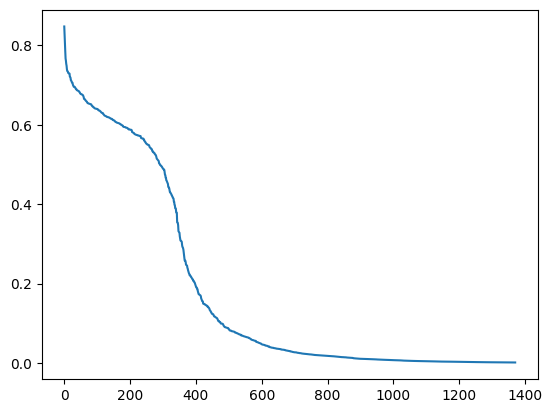

In [12]:
permutation = np.argsort(bb[:,6])[::-1] # descending
fig,ax = plt.subplots()
ax.plot(bb[permutation,6])

In [13]:
len(permutation)

1371

In [14]:
iouthresh = 0.3

In [15]:
gtlist = [g for g in gt_bb_adjusted]
# consider them in descending order
P = []
R = []
thresh = []
closest = []
ious = []
TP = 0
FP = 0
total = 0
NGT = gt_bb_adjusted.shape[0]
for i in range(len(permutation)):
    print(f'Starting {i}, confidence {bb[permutation[i],6]}')
    maxiou = -1.0
    maxiouind = -1
    for j in range(len(gtlist)): # this will change every loop
        iou = get_iou(bb[permutation[i]], gtlist[j])
        
        if iou > maxiou:
            maxiouind = j
            maxiou = iou
    print(f'Found best match {gtlist[maxiouind][-1]}, with iou {maxiou}')
    total += 1
    closest.append( gtlist[maxiouind][-1] )
    ious.append(maxiou)
    if maxiou > iouthresh: # this is a TP        
        TP += 1        
        # remove this from the list
        gtlist.pop(maxiouind)    
    else: # this is a false positive
        FP += 1
    P.append(  TP/total   ) # total = tp + fp
    R.append( TP/ NGT)
    thresh.append(bb[permutation[i],6])
    
        

Starting 0, confidence 0.8478826284408569
Found best match 268, with iou 0.3585573060824548
Starting 1, confidence 0.8244631290435791
Found best match 2, with iou 0
Starting 2, confidence 0.8008278012275696
Found best match 120, with iou 0.7342414443810351
Starting 3, confidence 0.7853843569755554
Found best match 162, with iou 0.5471341296247864
Starting 4, confidence 0.7671809196472168
Found best match 32, with iou 0.31017035327955594
Starting 5, confidence 0.7615929245948792
Found best match 2, with iou 0
Starting 6, confidence 0.7535291314125061
Found best match 188, with iou 0.7504263461059342
Starting 7, confidence 0.7490289807319641
Found best match 262, with iou 0.5313187163064814
Starting 8, confidence 0.7403597235679626
Found best match 25, with iou 0.619744609754942
Starting 9, confidence 0.7355158925056458
Found best match 30, with iou 0.2869745126344251
Starting 10, confidence 0.7350231409072876
Found best match 195, with iou 0.7561514546081516
Starting 11, confidence 0.73

In [19]:
# note I'm seeing a lot of guys with high confidence matching to 2
print(P[-1], R[-1], TP, FP)

0.162654996353027 0.8079710144927537 223 1148


In [24]:
Psave = P
Rsave = R
tsave = thresh

In [25]:
len( np.unique( closest ) ) # almost all of them get detected eventually


274

In [26]:
len(gtlist)

53

In [27]:
# some get detected a lot
# one of them seems to get detected 3000 times
from collections import Counter
Counter(zip(closest)) 


Counter({(np.int64(2),): 813,
         (np.int64(129),): 38,
         (np.int64(4),): 21,
         (np.int64(214),): 14,
         (np.int64(11),): 11,
         (np.int64(5),): 11,
         (np.int64(77),): 8,
         (np.int64(64),): 8,
         (np.int64(62),): 7,
         (np.int64(270),): 7,
         (np.int64(275),): 7,
         (np.int64(243),): 7,
         (np.int64(36),): 7,
         (np.int64(40),): 6,
         (np.int64(264),): 6,
         (np.int64(267),): 6,
         (np.int64(51),): 6,
         (np.int64(127),): 6,
         (np.int64(189),): 6,
         (np.int64(218),): 6,
         (np.int64(238),): 5,
         (np.int64(244),): 5,
         (np.int64(18),): 5,
         (np.int64(38),): 5,
         (np.int64(7),): 5,
         (np.int64(273),): 5,
         (np.int64(192),): 5,
         (np.int64(48),): 5,
         (np.int64(136),): 5,
         (np.int64(156),): 5,
         (np.int64(30),): 4,
         (np.int64(13),): 4,
         (np.int64(210),): 4,
         (np.int64(272)

In [28]:
Counter(zip(closest,ious)) 

Counter({(np.int64(2), 0): 807,
         (np.int64(4), 0): 13,
         (np.int64(5), 0): 3,
         (np.int64(268), np.float64(0.3585573060824548)): 1,
         (np.int64(120), np.float64(0.7342414443810351)): 1,
         (np.int64(162), np.float64(0.5471341296247864)): 1,
         (np.int64(32), np.float64(0.31017035327955594)): 1,
         (np.int64(188), np.float64(0.7504263461059342)): 1,
         (np.int64(262), np.float64(0.5313187163064814)): 1,
         (np.int64(25), np.float64(0.619744609754942)): 1,
         (np.int64(30), np.float64(0.2869745126344251)): 1,
         (np.int64(195), np.float64(0.7561514546081516)): 1,
         (np.int64(174), np.float64(0.013068194729719087)): 1,
         (np.int64(13), np.float64(0.18720510006194666)): 1,
         (np.int64(234), np.float64(0.6706067415455993)): 1,
         (np.int64(233), np.float64(0.3047449455882836)): 1,
         (np.int64(207), np.float64(0.4540274579462702)): 1,
         (np.int64(225), np.float64(0.4791391434312538

In [29]:
# often one label is detected thousands of times, so many false positives!
gt_bb_adjusted[0]

array([ 36,  52,  94, 106,  -2,   4,   2])

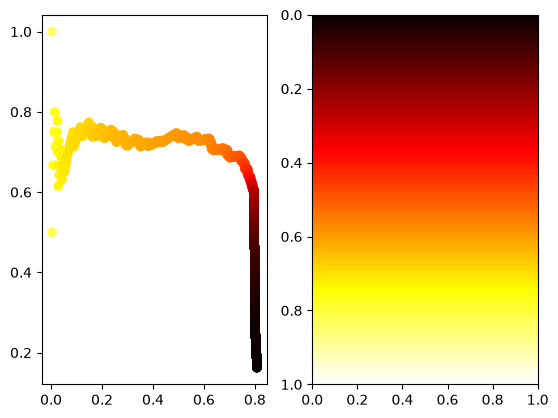

In [30]:
fig,ax = plt.subplots(1,2)
ax[0].scatter(R,P,c=plt.cm.hot(np.stack(thresh)))
ax[1].imshow(plt.cm.hot(np.linspace(0,1,100))[:,None],aspect='auto',extent=(0,1,1,0))


Starting 0, confidence 0.8478826284408569
Found best match 268, with iou 0.3585573060824548
Starting 1, confidence 0.8244631290435791
Found best match 2, with iou 0
Starting 2, confidence 0.8008278012275696
Found best match 120, with iou 0.7342414443810351
Starting 3, confidence 0.7853843569755554
Found best match 162, with iou 0.5471341296247864
Starting 4, confidence 0.7671809196472168
Found best match 32, with iou 0.31017035327955594
Starting 5, confidence 0.7615929245948792
Found best match 2, with iou 0
Starting 6, confidence 0.7535291314125061
Found best match 188, with iou 0.7504263461059342
Starting 7, confidence 0.7490289807319641
Found best match 262, with iou 0.5313187163064814
Starting 8, confidence 0.7403597235679626
Found best match 25, with iou 0.619744609754942
Starting 9, confidence 0.7355158925056458
Found best match 30, with iou 0.2869745126344251
Starting 10, confidence 0.7350231409072876
Found best match 195, with iou 0.7561514546081516
Starting 11, confidence 0.73

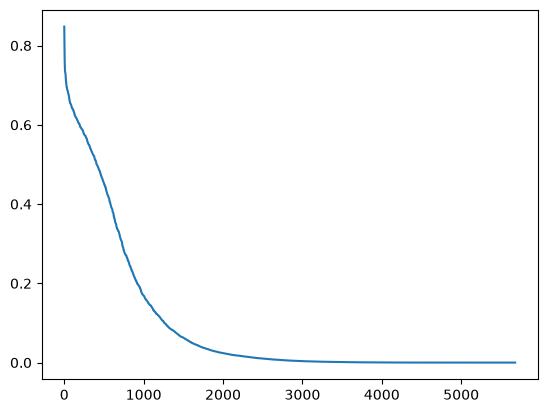

In [31]:
bb = yolo_bb_adjusted0.copy()
#bb = yolo_bb_adjusted.copy()

# only keep the boxes that are inside
inds = np.all( bb[:,[1,3,5]] > -0.5, 1) # these are the right sides
# and the left sides
inds = inds *  np.all( bb[:,[0,2,4]] < 127.5, 1)

bb = bb[inds]



permutation = np.argsort(bb[:,6])[::-1] # descending
fig,ax = plt.subplots()
ax.plot(bb[permutation,6])


gtlist = [g for g in gt_bb_adjusted]
# consider them in descending order
P = []
R = []
thresh = []
closest = []
ious = []
TP = 0
FP = 0
total = 0
NGT = gt_bb_adjusted.shape[0]
for i in range(len(permutation)):
    confidence = bb[permutation[i],6]
    print(f'Starting {i}, confidence {confidence}')
    if confidence < conf_thresh:
        break
    maxiou = -1.0
    maxiouind = -1
    for j in range(len(gtlist)): # this will change every loop
        iou = get_iou(bb[permutation[i]], gtlist[j])
        
        if iou > maxiou:
            maxiouind = j
            maxiou = iou
    print(f'Found best match {gtlist[maxiouind][-1]}, with iou {maxiou}')
    total += 1
    closest.append( gtlist[maxiouind][-1] )
    ious.append(maxiou)
    if maxiou > iouthresh: # this is a TP        
        TP += 1        
        # remove this from the list
        gtlist.pop(maxiouind)    
    else: # this is a false positive
        FP += 1
    P.append(  TP/total   ) # total = tp + fp
    R.append( TP/ NGT)
    thresh.append(bb[permutation[i],6])
        

In [20]:
print(P[-1], R[-1], TP, FP)


0.162654996353027 0.8079710144927537 223 1148


Text(0.5, 0.98, 'PR Curves, correct iou thresh: 0.3, \nminimum conf thresh: 0.001, nms iou thresh: 0.3')

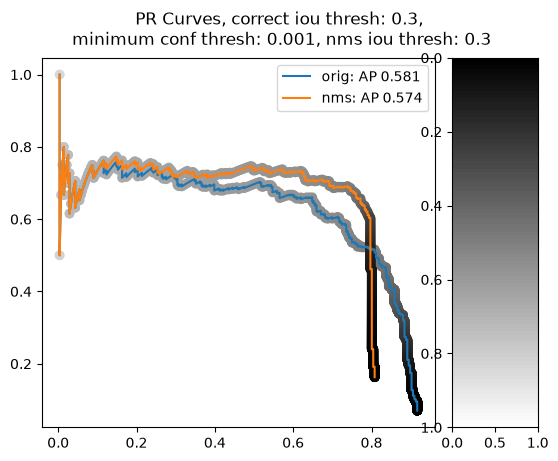

In [32]:

# get the AP
# trapezoid  rul
AP = np.sum( np.diff( np.array(R) ) * (np.array(P)[:-1] + np.array(P)[1:])/2 ) # orig
APsave = np.sum( np.diff( np.array(Rsave) )* (np.array(Psave)[:-1] + np.array(Psave)[1:])/2 ) # NMS

cmap = plt.cm.gray
fig,ax = plt.subplot_mosaic('00001')
ax['0'].scatter(R,P,c=cmap(np.stack(thresh)))
ax['0'].scatter(Rsave,Psave,c=cmap(np.stack(tsave)))
ax['0'].plot(R,P,label=f'orig: AP {AP:.3f}')
ax['0'].plot(Rsave,Psave,label=f'nms: AP {APsave:.3f}')
ax['1'].imshow(cmap(np.linspace(0,1,100))[:,None],aspect='auto',extent=(0,1,1,0))
ax['0'].legend()

fig.suptitle(f'PR Curves, correct iou thresh: {iouthresh}, \nminimum conf thresh: {conf_thresh}, nms iou thresh: {nms_thresh}')



In [33]:
AP,APsave # apsave is nms, the one on the right


(np.float64(0.5806365287962622), np.float64(0.5743023405222626))

In [34]:
raise Exception('done')

Exception: done

In [ ]:
# [idx, best_gt_iou_idx, pred_conf, best_gt_iou, TP, FP, total_TP, total_FP, precision, recall]

# for elem in perf_star:
#     print(elem)

# for elem in star_bb:
#     print(elem)

cell_bb[20]

In [ ]:
for idx, elem in enumerate(perf_yolo):
    if idx % 500 == 0:
        print(elem)
    if idx > 10000:
        break

### Compute mAP (0.5:0.05:1.0) for each model

In [ ]:
all_mAP = []
for all_bb in [yolo_bb, star_bb, cell_bb]:
    rolling_AP = 0
    for iou in np.arange(0.5,1,0.05):
        AP, performance = get_AP(gt_bb, all_bb, iou_thresh = iou, verbose = False)
        rolling_AP += AP
    mAP = rolling_AP / 10
    all_mAP.append(mAP)

### Plot Results?